# Retail Customer Intelligence System
## Notebook 1: Data Ingestion and Exploratory Data Analysis

### Objective
This notebook performs the initial loading, inspection, and exploratory analysis of the retail customer dataset. It focuses on understanding data structure, missing values, duplicates, feature distributions, and initial patterns that will guide preprocessing and feature engineering in later stages.

In [28]:

# Retail Customer Intelligence System
# Notebook 1: Data Ingestion and EDA

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Libraries imported successfully.")

Libraries imported successfully.


In [29]:
# -------------------------------
# 2. Load Dataset
# -------------------------------

file_path = "online_retail_II.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print(f"Shape of dataset: {df.shape}")

Dataset loaded successfully.
Shape of dataset: (541910, 8)


In [30]:

df.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01/12/2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01/12/2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01/12/2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01/12/2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01/12/2010 08:26,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,01/12/2010 08:26,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,01/12/2010 08:26,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,01/12/2010 08:28,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,01/12/2010 08:28,1.85,17850.0,United Kingdom
9,536368,22960,JAM MAKING SET WITH JARS,6,01/12/2010 08:34,4.25,13047.0,United Kingdom


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      541910 non-null  object 
 1   StockCode    541910 non-null  object 
 2   Description  540456 non-null  object 
 3   Quantity     541910 non-null  int64  
 4   InvoiceDate  541910 non-null  object 
 5   Price        541910 non-null  float64
 6   Customer ID  406830 non-null  float64
 7   Country      541910 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [32]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Invoice,541910,25900,573585,1114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,541910,4070,85123A,2313,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,540456,4223,WHITE HANGING HEART T-LIGHT HOLDER,2369,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,541910.0,NaN,NaN,NaN,9.552234,218.080957,-80995.0,1.0,3.0,10.0,80995.0
InvoiceDate,541910,23260,31/10/2011 14:41,1114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price,541910.0,NaN,NaN,NaN,4.611138,96.759765,-11062.06,1.25,2.08,4.13,38970.0
Customer ID,406830.0,NaN,NaN,NaN,15287.68416,1713.603074,12346.0,13953.0,15152.0,16791.0,18287.0
Country,541910,38,United Kingdom,495478,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [33]:
print("Columns in dataset:")
for col in df.columns:
    print("-", col)

Columns in dataset:
- Invoice
- StockCode
- Description
- Quantity
- InvoiceDate
- Price
- Customer ID
- Country


In [34]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_percent = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

missing_df = pd.DataFrame({
    "Missing Count": missing_values,
    "Missing %": missing_percent
})

missing_df[missing_df["Missing Count"] > 0]

,Missing Count,Missing %
Customer ID,135080,24.926648
Description,1454,0.268310


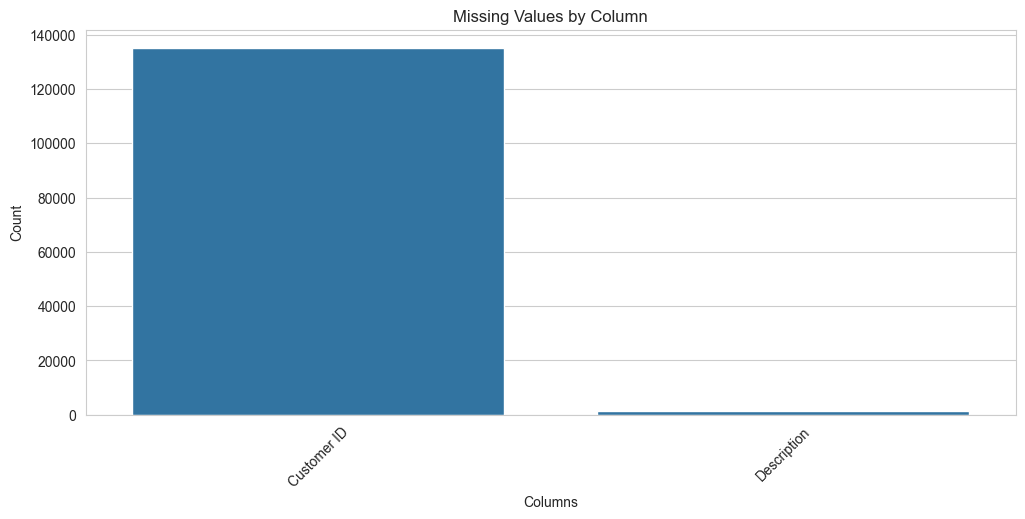

In [35]:
missing_plot = missing_df[missing_df["Missing Count"] > 0]

if len(missing_plot) > 0:
    plt.figure(figsize=(12, 5))
    sns.barplot(x=missing_plot.index, y=missing_plot["Missing Count"])
    plt.title("Missing Values by Column")
    plt.xticks(rotation=45)
    plt.ylabel("Count")
    plt.xlabel("Columns")
    plt.show()
else:
    print("No missing values found.")

In [36]:
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 5268


In [37]:
dtype_df = pd.DataFrame(df.dtypes, columns=["Data Type"])
dtype_df

,Data Type
Invoice,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,object
Price,float64
Customer ID,float64
Country,object


In [38]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numeric Columns:")
print(numeric_cols)

print("\nCategorical Columns:")
print(categorical_cols)

Numeric Columns:
['Quantity', 'Price', 'Customer ID']

Categorical Columns:
['Invoice', 'StockCode', 'Description', 'InvoiceDate', 'Country']


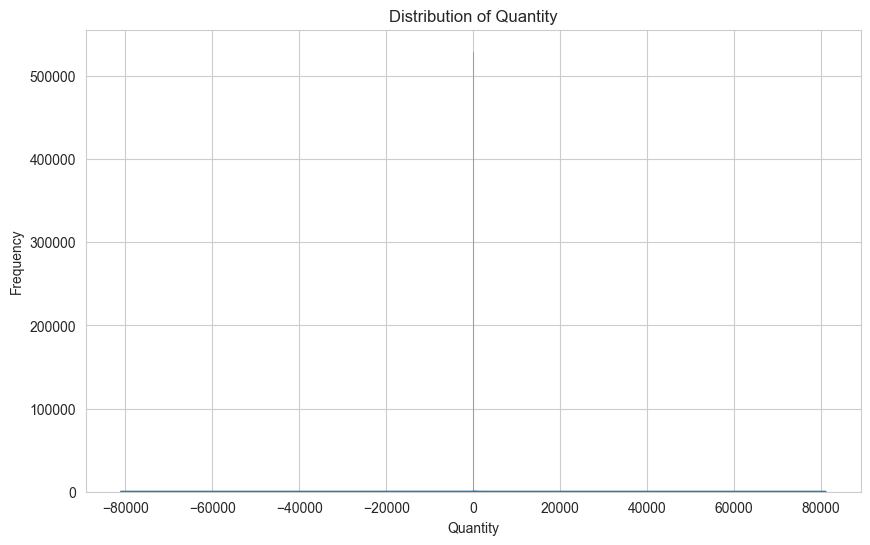

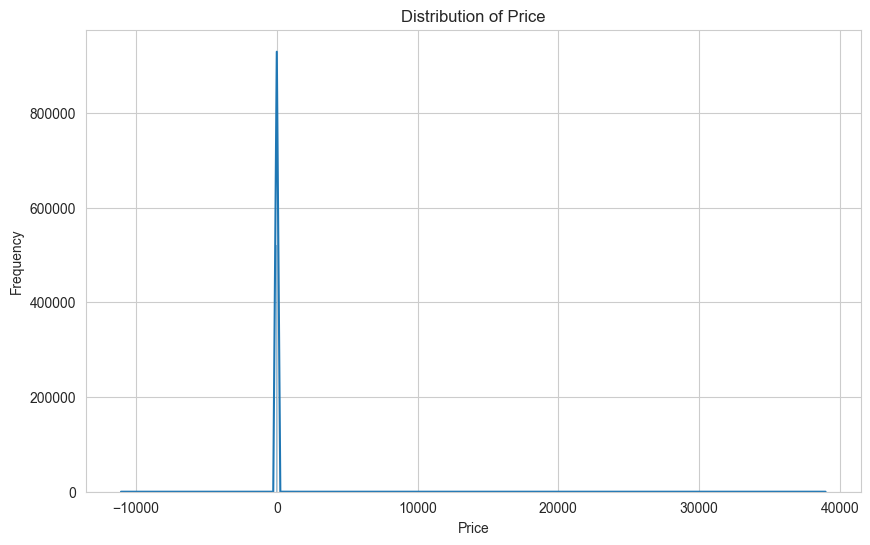

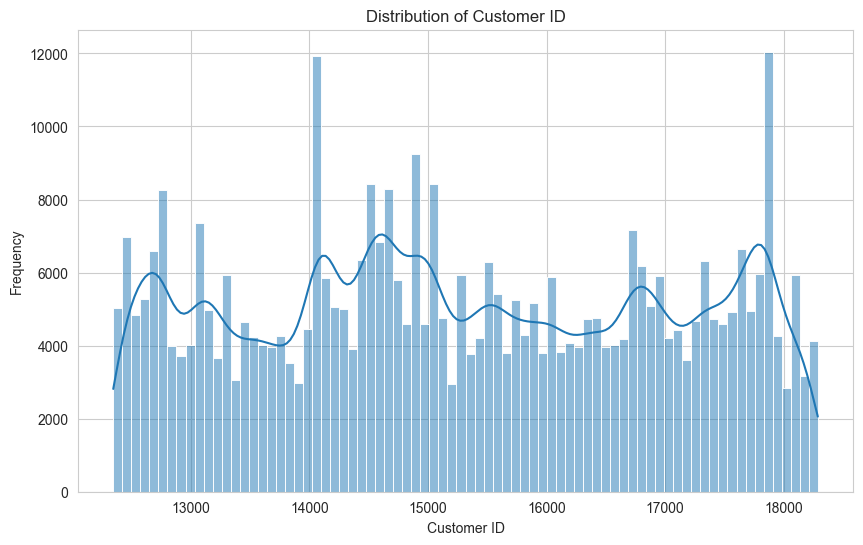

In [39]:
for col in numeric_cols:
    plt.figure()
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

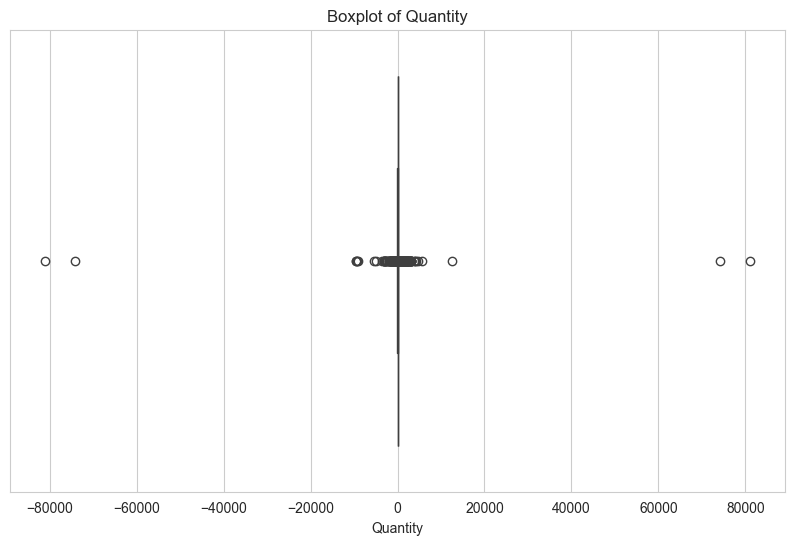

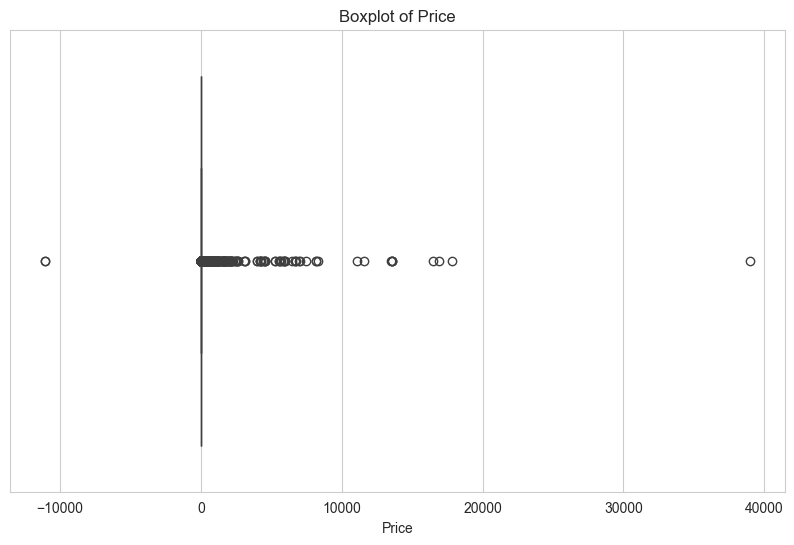

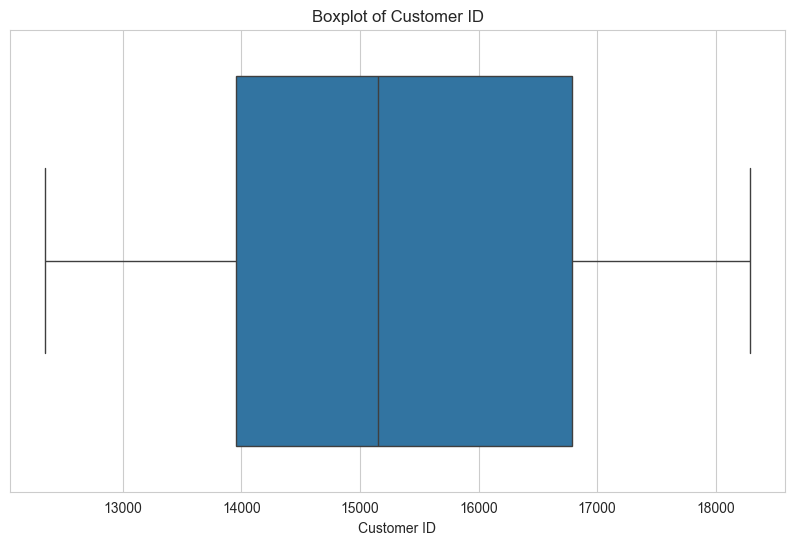

In [40]:
for col in numeric_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

In [42]:
for col in categorical_cols:
    print(f"\nValue counts for {col}:")
    print(df[col].value_counts(dropna=False).head(10))


Value counts for Invoice:
Invoice
573585    1114
581219     749
581492     731
580729     721
558475     705
579777     687
581217     676
537434     675
580730     662
538071     652
Name: count, dtype: int64

Value counts for StockCode:
StockCode
85123A    2313
22423     2203
85099B    2159
47566     1727
20725     1639
84879     1502
22720     1477
22197     1476
21212     1385
20727     1350
Name: count, dtype: int64

Value counts for Description:
Description
WHITE HANGING HEART T-LIGHT HOLDER    2369
REGENCY CAKESTAND 3 TIER              2200
JUMBO BAG RED RETROSPOT               2159
PARTY BUNTING                         1727
LUNCH BAG RED RETROSPOT               1638
ASSORTED COLOUR BIRD ORNAMENT         1501
SET OF 3 CAKE TINS PANTRY DESIGN      1473
NaN                                   1454
PACK OF 72 RETROSPOT CAKE CASES       1385
LUNCH BAG  BLACK SKULL.               1350
Name: count, dtype: int64

Value counts for InvoiceDate:
InvoiceDate
31/10/2011 14:41    1114
08/12/2

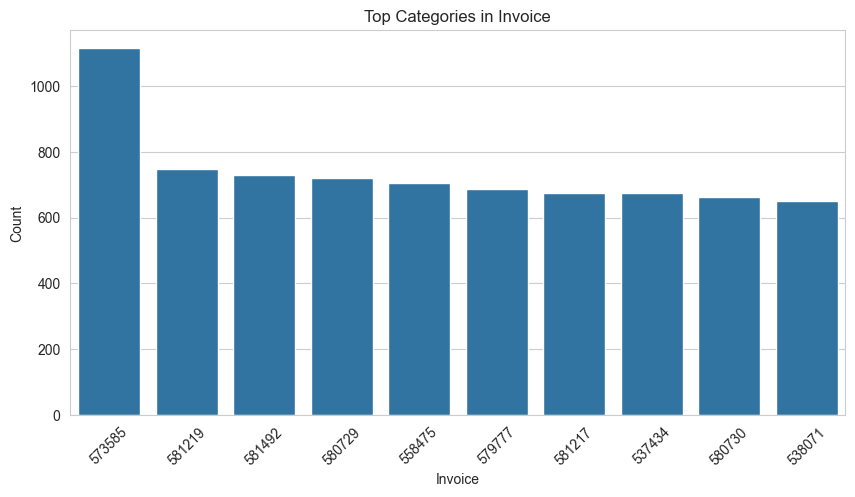

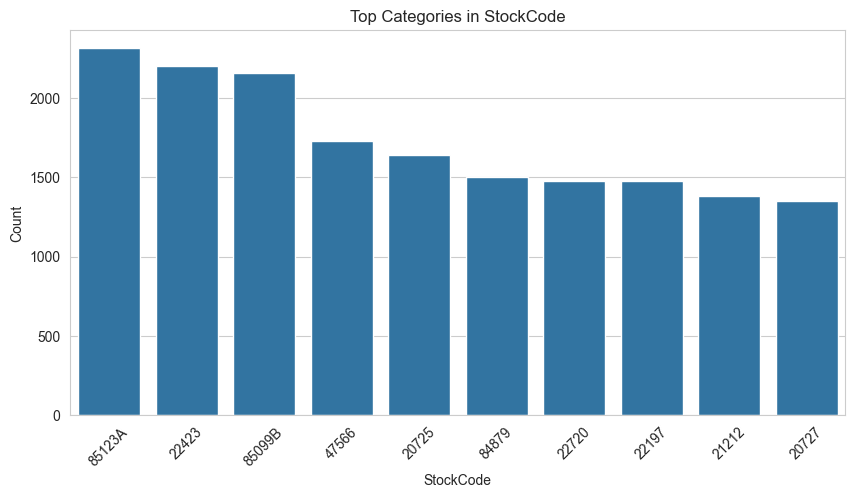

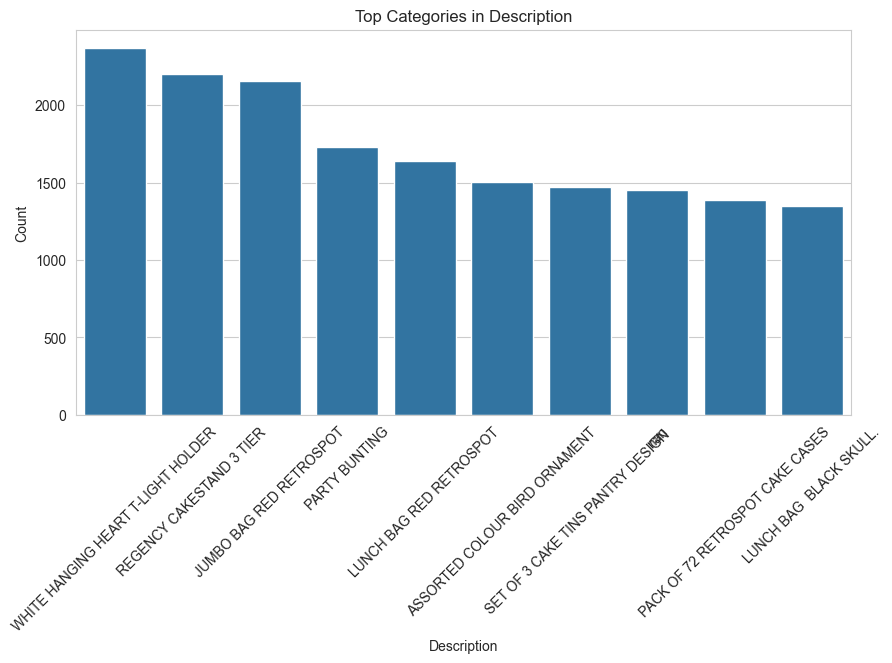

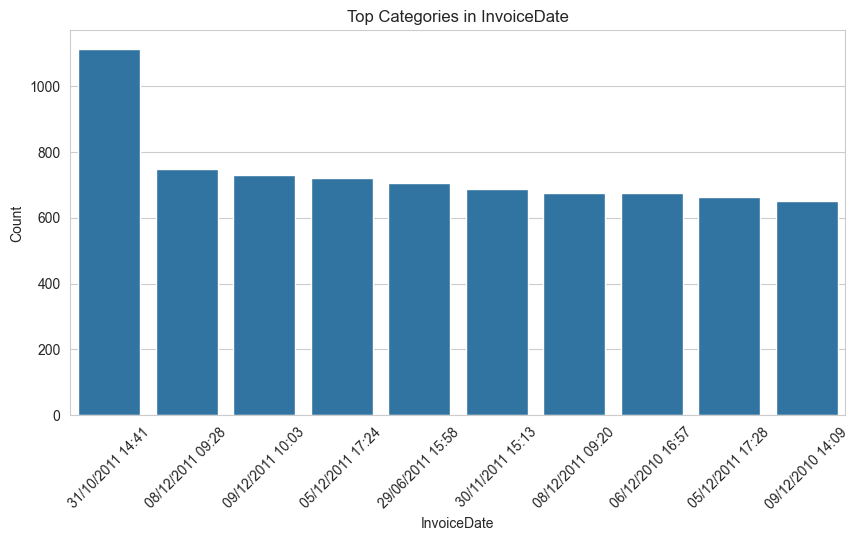

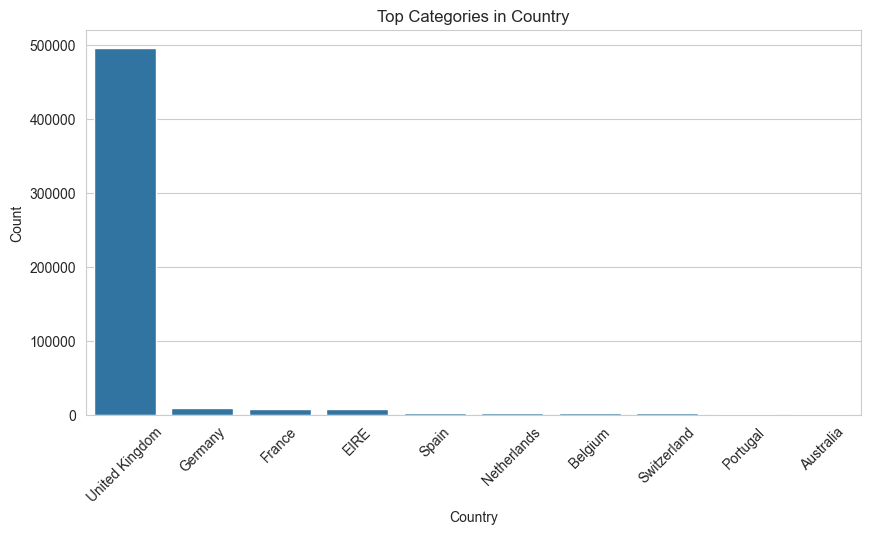

In [43]:
for col in categorical_cols:
    plt.figure(figsize=(10, 5))
    top_counts = df[col].value_counts(dropna=False).head(10)
    sns.barplot(x=top_counts.index.astype(str), y=top_counts.values)
    plt.title(f"Top Categories in {col}")
    plt.xticks(rotation=45)
    plt.ylabel("Count")
    plt.xlabel(col)
    plt.show()

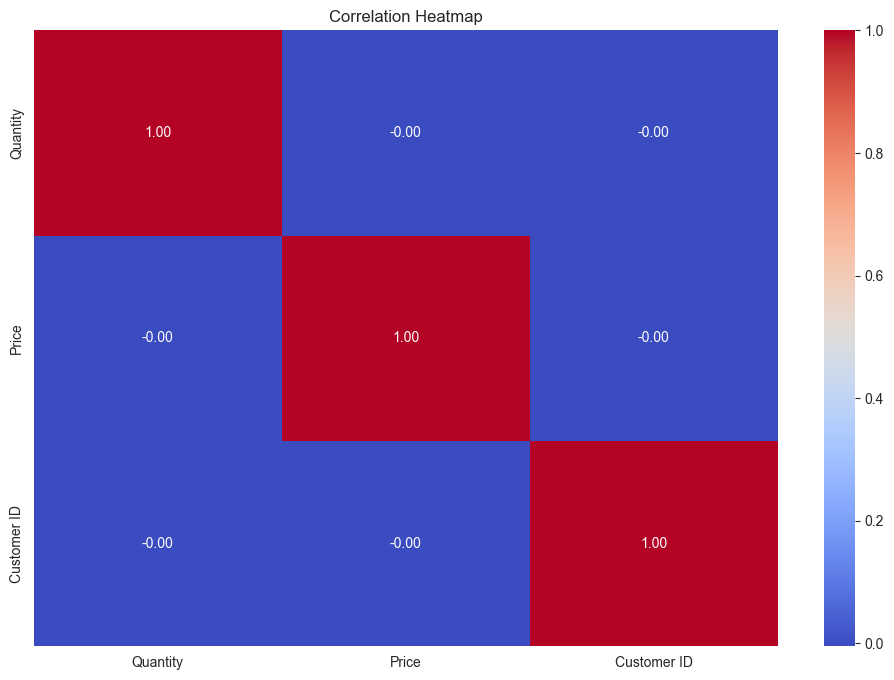

In [44]:
if len(numeric_cols) > 1:
    corr = df[numeric_cols].corr()

    plt.figure(figsize=(12, 8))
    sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Correlation Heatmap")
    plt.show()
else:
    print("Not enough numeric columns for correlation heatmap.")

In [45]:
outlier_summary = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_summary[col] = len(outliers)

outlier_df = pd.DataFrame.from_dict(outlier_summary, orient="index", columns=["Outlier Count"])
outlier_df.sort_values(by="Outlier Count", ascending=False)

,Outlier Count
Quantity,58619
Price,39628
Customer ID,0


In [46]:
if "churn_flag" in df.columns:
    print(df["churn_flag"].value_counts())

    plt.figure()
    sns.countplot(x="churn_flag", data=df)
    plt.title("Distribution of churn_flag")
    plt.show()
else:
    print("Column 'churn_flag' not found in dataset.")

Column 'churn_flag' not found in dataset.


In [47]:
if "future_spend" in df.columns:
    plt.figure()
    sns.histplot(df["future_spend"].dropna(), kde=True)
    plt.title("Distribution of future_spend")
    plt.xlabel("future_spend")
    plt.show()
else:
    print("Column 'future_spend' not found in dataset.")

Column 'future_spend' not found in dataset.


In [48]:
possible_date_cols = [col for col in df.columns if "date" in col.lower()]

if possible_date_cols:
    print("Possible date columns found:", possible_date_cols)
else:
    print("No obvious date columns found.")

Possible date columns found: ['InvoiceDate']


In [49]:
print("===== DATASET SUMMARY =====")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print(f"Duplicate rows: {duplicate_count}")
print(f"Numeric columns: {len(numeric_cols)}")
print(f"Categorical columns: {len(categorical_cols)}")
print("\nTop missing values:")
print(missing_df[missing_df["Missing Count"] > 0].head(10))

===== DATASET SUMMARY =====
Rows: 541910
Columns: 8
Duplicate rows: 5268
Numeric columns: 3
Categorical columns: 5

Top missing values:
             Missing Count  Missing %
Customer ID         135080  24.926648
Description           1454   0.268310


In [50]:
output_dir = Path("data/processed")
output_dir.mkdir(parents=True, exist_ok=True)

output_path = output_dir / "retail_customers_stage1.csv"
df.to_csv(output_path, index=False)

print(f"Stage 1 dataset saved to: {output_path}")

Stage 1 dataset saved to: data\processed\retail_customers_stage1.csv
